# **Introduction**

Earnings announcements are a key event in financial markets, often triggering significant stock price movement. Investors closely monitor the difference between expected and actual earnings, commonly referred to as earnings surprise.
Predicting how stocks will react to earnings announcements remains challenging due to market complexity and external factors. This study aims to analyze whether earnings surprise can be used to estimate expected stock price movement and evaluate its predictive power.

In [2]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['axes.facecolor'] = 'f8f9fa'


import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import os


# **Data**

In [3]:
import kagglehub

# Download latest version
earnings = kagglehub.dataset_download("tsaustin/us-historical-stock-prices-with-earnings-data")

print("Path to dataset files:", earnings)

path = earnings
print(os.listdir(path))

os.listdir(f"{path}/stocks_latest")

Using Colab cache for faster access to the 'us-historical-stock-prices-with-earnings-data' dataset.
Path to dataset files: /kaggle/input/us-historical-stock-prices-with-earnings-data
['stocks_latest', 'dataset_summary.csv']


['dividends_latest.csv', 'earnings_latest.csv', 'stock_prices_latest.csv']

In [4]:
prices = pd.read_csv(f"{path}/stocks_latest/stock_prices_latest.csv")
earnings = pd.read_csv(f"{path}/stocks_latest/earnings_latest.csv")

First inspect and clean the stock prices CSV:

In [5]:
prices.info()
prices.describe()
print(prices.head())
print("\nMissing values per column:\n")
prices.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24395016 entries, 0 to 24395015
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   symbol             object 
 1   date               object 
 2   open               float64
 3   high               float64
 4   low                float64
 5   close              float64
 6   close_adjusted     float64
 7   volume             int64  
 8   split_coefficient  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 1.6+ GB
  symbol        date   open   high    low  close  close_adjusted     volume  \
0   MSFT  2016-05-16  50.80  51.96  50.75  51.83         49.7013   20032017   
1   MSFT  2002-01-16  68.85  69.84  67.85  67.87         22.5902   30977700   
2   MSFT  2001-09-18  53.41  55.00  53.17  54.32         18.0802   41591300   
3   MSFT  2007-10-26  36.01  36.03  34.56  35.03         27.2232  288121200   
4   MSFT  2014-06-27  41.61  42.29  41.51  42.25         38.6773   74640000  

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
close_adjusted,0
volume,0
split_coefficient,0


In [6]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24395016 entries, 0 to 24395015
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   symbol             object 
 1   date               object 
 2   open               float64
 3   high               float64
 4   low                float64
 5   close              float64
 6   close_adjusted     float64
 7   volume             int64  
 8   split_coefficient  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 1.6+ GB


In [7]:
#convert Date

prices['date'] = pd.to_datetime(prices['date'])

#keep columns needed

prices = prices[['symbol', 'date', 'open', 'close_adjusted']]

#convert column name from symbol to ticker

prices = prices.rename(columns={'symbol': 'ticker'})

#sort by date

prices = prices.sort_values(by=['ticker', 'date'])
prices.info()


<class 'pandas.core.frame.DataFrame'>
Index: 24395016 entries, 19762470 to 24379776
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   ticker          object        
 1   date            datetime64[ns]
 2   open            float64       
 3   close_adjusted  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 930.6+ MB


Next, inspect and clean the earnings CSV:

In [8]:
earnings.info()
print(earnings.head())
print("\nMissing values per column:\n")
earnings.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168603 entries, 0 to 168602
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   symbol        168603 non-null  object 
 1   date          168603 non-null  object 
 2   qtr           167599 non-null  object 
 3   eps_est       111347 non-null  float64
 4   eps           136216 non-null  float64
 5   release_time  108400 non-null  object 
dtypes: float64(2), object(4)
memory usage: 7.7+ MB
  symbol        date      qtr  eps_est  eps release_time
0      A  2009-05-14  04/2009      NaN  NaN         post
1      A  2009-08-17  07/2009      NaN  NaN         post
2      A  2009-11-13  10/2009      NaN  NaN          pre
3      A  2010-02-12  01/2010      NaN  NaN          pre
4      A  2010-05-17  04/2010      NaN  NaN         post

Missing values per column:



,0
symbol,0
date,0
qtr,1004
eps_est,57256
eps,32387
release_time,60203


In [9]:
#keep columns needed

earnings = earnings[['symbol', 'date', 'eps_est', 'eps',]]

#convert column name from symbol to ticker
earnings = earnings.rename(columns={'symbol': 'ticker'})

#drop missing rows
earnings = earnings.dropna(subset=['eps_est', 'eps'])

#add new variable used for models

earnings['eps_surprise'] = earnings['eps'] - earnings['eps_est']

#convert Date

earnings['date'] = pd.to_datetime(earnings['date'])


New columns were created to generate dates one day before and one day after each earnings announcement, allowing the prices immediately surrounding the earnings event to be retrieved easily. The stock price and earnings datasets were then sorted to ensure the tables could be merged correctly. After merging the datasets, the resulting tables were reviewed and printed to verify accuracy.

In [10]:
# make copies so we don't overwrite original dates
earnings_before = earnings.copy()
earnings_after = earnings.copy()

#shift dates

earnings_before['lookup_date'] = earnings_before['date'] - pd.Timedelta(days=1)
earnings_after['lookup_date'] = earnings_after['date'] + pd.Timedelta(days=1)

# sort
prices_sorted = prices.sort_values(['date', 'ticker']).reset_index(drop=True)
earnings_before = earnings_before.sort_values(['lookup_date', 'ticker']).reset_index(drop=True)
earnings_after = earnings_after.sort_values(['lookup_date', 'ticker']).reset_index(drop=True)

# price before earnings
price_before = pd.merge_asof(
    earnings_before,
    prices_sorted,
    by='ticker',
    left_on='lookup_date',
    right_on='date',
    direction='backward'
)


print("Price Before Table:\n")
price_before.head()


Price Before Table:



,ticker,date_x,eps_est,eps,eps_surprise,lookup_date,date_y,open,close_adjusted
0,C,2012-07-16,0.88,0.95,0.07,2012-07-15,2012-07-13,25.5800,25.8879
1,CSX,2012-07-17,0.47,0.49,0.02,2012-07-16,2012-07-16,22.5700,20.0224
2,FIS,2012-07-17,0.60,0.66,0.06,2012-07-16,2012-07-16,34.1200,31.2681
3,INTC,2012-07-17,0.52,0.54,0.02,2012-07-16,2012-07-16,25.2259,21.0032
4,WYNN,2012-07-17,1.48,1.38,-0.10,2012-07-16,2012-07-16,96.0300,95.7549


In [11]:
price_after = pd.merge_asof(
    earnings_after,
    prices_sorted,
    by='ticker',
    left_on='lookup_date',
    right_on='date',
    direction='forward'
)

print("Price After Table:\n")
price_after.head()

Price After Table:



,ticker,date_x,eps_est,eps,eps_surprise,lookup_date,date_y,open,close_adjusted
0,C,2012-07-16,0.88,0.95,0.07,2012-07-17,2012-07-17,27.130,26.5970
1,CSX,2012-07-17,0.47,0.49,0.02,2012-07-18,2012-07-18,22.810,20.0579
2,FIS,2012-07-17,0.60,0.66,0.06,2012-07-18,2012-07-18,33.790,30.2015
3,INTC,2012-07-17,0.52,0.54,0.02,2012-07-18,2012-07-18,25.195,21.9058
4,WYNN,2012-07-17,1.48,1.38,-0.10,2012-07-18,2012-07-18,96.250,95.6060


The earnings and stock price data were combined into one final analysis table. It selects the key variables related to earnings performance and stock prices, then creates additional features including the absolute earnings surprise, surprise percentage, and stock price percentage change after earnings. Columns were also renamed for clarity and prepares the dataset for later statistical analysis and predictive modeling.

In [12]:
final = price_before[['ticker', 'date_x', 'eps', 'eps_est', 'eps_surprise', 'close_adjusted']].copy()

final['abs_surprise'] = abs(final['eps_surprise'])
final['surprise_pct'] = final['eps_surprise'] / abs(final['eps_est'])

final = final.rename(columns={
    'date_x': 'earnings_date',
    'close_adjusted': 'price_before'
})

final['price_after'] = price_after['close_adjusted']

final['pct_change'] = (
    (final['price_after'] - final['price_before'])
    / final['price_before']
)

final.head()

,ticker,earnings_date,eps,eps_est,eps_surprise,price_before,abs_surprise,surprise_pct,price_after,pct_change
0,C,2012-07-16,0.95,0.88,0.07,25.8879,0.07,0.079545,26.5970,0.027391
1,CSX,2012-07-17,0.49,0.47,0.02,20.0224,0.02,0.042553,20.0579,0.001773
2,FIS,2012-07-17,0.66,0.60,0.06,31.2681,0.06,0.100000,30.2015,-0.034111
3,INTC,2012-07-17,0.54,0.52,0.02,21.0032,0.02,0.038462,21.9058,0.042974
4,WYNN,2012-07-17,1.38,1.48,-0.10,95.7549,0.10,-0.067568,95.6060,-0.001555


This section groups earnings surprises into ranges to evaluate how different levels of EPS surprise relate to stock price reactions. A binary variable was also created to indicate whether the stock price increased after earnings. The data was then summarized by EPS surprise range to calculate the number of observations, average price change, median price change, and probability that the stock increase

In [13]:
#create EPS ranges

final['eps_bin'] = pd.cut(
    final['eps_surprise'],
    bins=[-10, -1, -0.5, -0.1, 0.1, 0.5, 1, 10]
)

#Create binary variable

final['went_up'] = (final['pct_change'] > 0).astype(int)

#summarize expected move

summary = final.groupby('eps_bin').agg(
    count=('pct_change', 'count'),
    avg_pct_change=('pct_change', 'mean'),
    median_pct_change=('pct_change', 'median'),
    probability_up=('went_up', 'mean')
).reset_index()

summary

#convert to percentages

summary['avg_pct_change'] = summary['avg_pct_change'] * 100
summary['median_pct_change'] = summary['median_pct_change'] * 100
summary['probability_up'] = summary['probability_up'] * 100

summary

,eps_bin,count,avg_pct_change,median_pct_change,probability_up
0,"(-10.0, -1.0]",1254,-2.545018,-1.901613,33.384263
1,"(-1.0, -0.5]",2032,-2.197448,-1.223731,36.164122
2,"(-0.5, -0.1]",11534,-3.171313,-1.960383,32.971506
3,"(-0.1, 0.1]",72954,0.061889,0.000000,48.285007
4,"(0.1, 0.5]",17596,2.836746,2.057456,63.181666
5,"(0.5, 1.0]",2046,2.844565,1.850747,61.640588
6,"(1.0, 10.0]",1220,2.770846,1.857930,58.893281


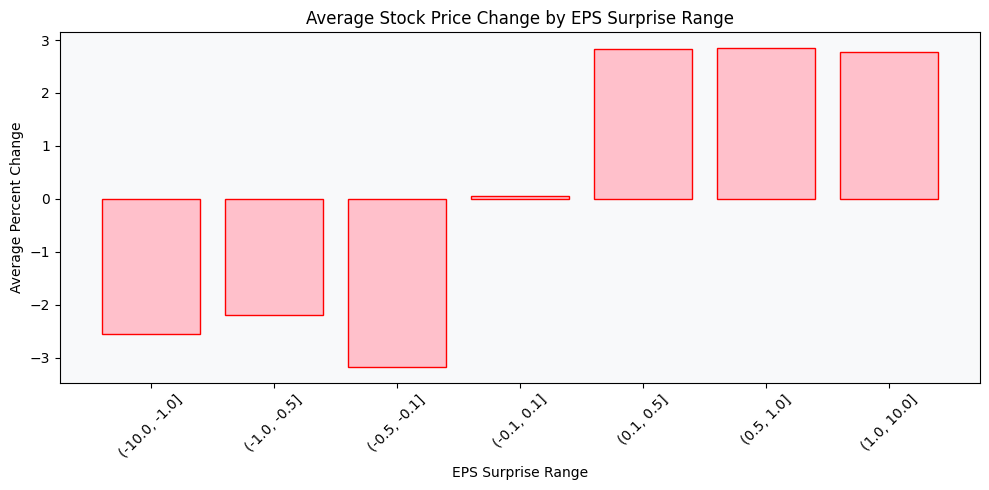

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    summary['eps_bin'].astype(str),
    summary['avg_pct_change'],
    color= 'pink',
    edgecolor='red'
)

plt.title('Average Stock Price Change by EPS Surprise Range')
plt.xlabel('EPS Surprise Range')
plt.ylabel('Average Percent Change')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

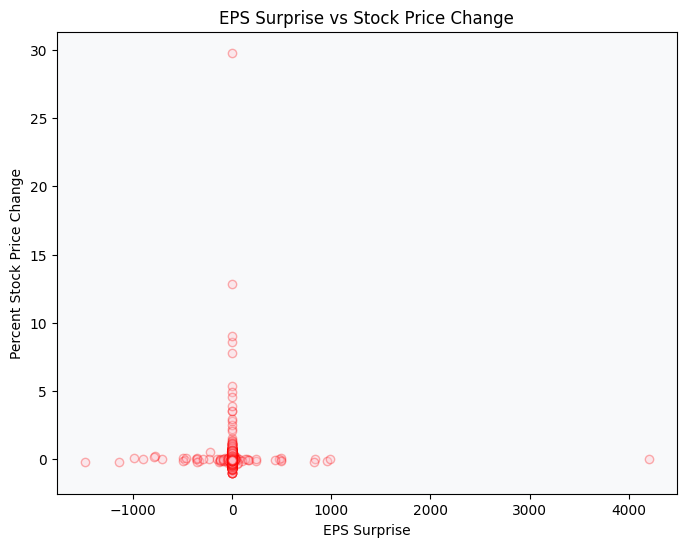

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    final['eps_surprise'],
    final['pct_change'],
    alpha=0.3,
    color='pink',
    edgecolor='red'
)

plt.xlabel('EPS Surprise')
plt.ylabel('Percent Stock Price Change')
plt.title('EPS Surprise vs Stock Price Change')

plt.show()

The scatterplot shows a very weak relationship between EPS surprise and stock price change, with observations widely dispersed and concentrated near zero. Several extreme outliers are present, but overall there is no clear linear trend.

# **Model Building**

In this section, the dataset was prepared for linear regression, random forest and logistic regression modeling. The data was then separated into predictor variables and the target variable, followed by splitting the dataset into training and testing sets. Feature scaling was applied using standardization to ensure all variables were on a consistent scale. Finally, the models were evaluated using R², MAE, and RMSE to measure prediction performance and error.

Linear Regression:

In [15]:
#Replace infinities
final = final.replace([np.inf, -np.inf], np.nan)

# drop rows where target or features are missing
final = final.dropna(subset=[
    'pct_change',
    'eps_surprise',
    'abs_surprise',
    'surprise_pct'
])

#define features and target
X = final[['eps_surprise', 'abs_surprise', 'surprise_pct']]
y = final['pct_change']

#train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train Linear Regression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

#Make predictions
y_pred = model.predict(X_test_scaled)


#Evaluate

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


R²: -0.0003759579501283472
MAE: 0.05958570029118695
RMSE: 0.10805685655568284


The linear regression model demonstrated extremely weak predictive performance, with an R² value slightly below zero (-0.0004), indicating that the model explains virtually none of the variation in stock price changes and performs worse than simply predicting the average return. The MAE of 0.0596 suggests that the model’s predictions were off by an average of approximately 5.96 percentage points, while the RMSE of 0.1081 indicates that larger prediction errors were also present. Overall, the results suggest that EPS surprise variables alone are not strong predictors of short-term stock price movement in this dataset.

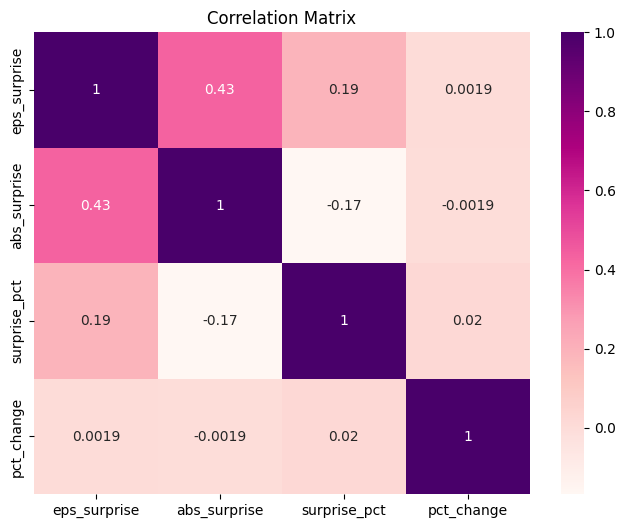

In [16]:
corr = final[['eps_surprise', 'abs_surprise',
              'surprise_pct', 'pct_change']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdPu'
)

plt.title('Correlation Matrix')
plt.show()

The correlation matrix further supports the weak performance of the linear regression model. The predictor variables all showed extremely weak correlations with stock price percentage change, with coefficients close to zero. This indicates that earnings surprise variables alone have little linear relationship with short-term stock price movement. While moderate relationships existed among some of the predictor variables themselves, none demonstrated meaningful predictive strength for explaining stock returns.

Random Forest:

In [17]:
#define features and target
X = final[['eps_surprise', 'abs_surprise', 'surprise_pct']]
y = final['went_up']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train random forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

#make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

#evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.5681502729712223

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.57      0.57     10871
           1       0.57      0.56      0.57     10743

    accuracy                           0.57     21614
   macro avg       0.57      0.57      0.57     21614
weighted avg       0.57      0.57      0.57     21614


Confusion Matrix:

[[6212 4659]
 [4675 6068]]


The Random Forest classification model demonstrated weak predictive performance, achieving an overall accuracy of 56.82%, only slightly better than random guessing for a binary classification problem. The model showed balanced performance across both classes, with precision, recall, and F1-scores all remaining near 0.57 for predicting whether a stock price would increase or decrease following an earnings announcement.

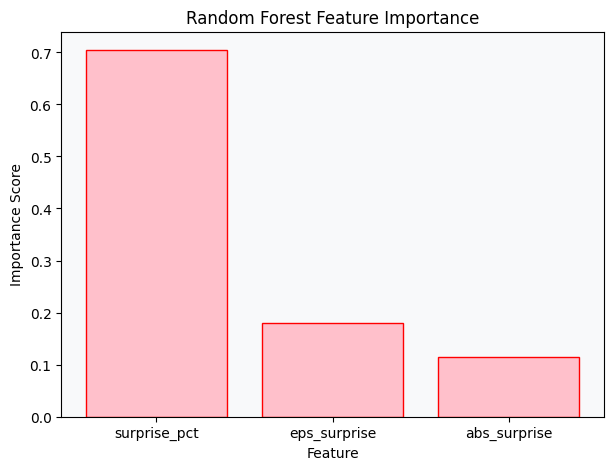

        Feature  Importance
2  surprise_pct    0.704814
0  eps_surprise    0.180070
1  abs_surprise    0.115117


In [25]:
#create importance dataframe
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

#sort values
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

#plot
plt.figure(figsize=(7,5))

plt.bar(
    importance['Feature'],
    importance['Importance'],
    color= 'pink',
    edgecolor='red'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')

plt.show()

print(importance)

The Random Forest feature importance analysis showed that surprise_pct was the most influential variable in predicting stock price direction, with an importance score of 0.705. This suggests that the relative size of the earnings surprise compared to analyst expectations contributed the most predictive information to the model. In comparison, eps_surprise had a substantially lower importance score of 0.180, while abs_surprise contributed the least with a score of 0.115.

Logistic Regression:

In [18]:
#define target
y = final['went_up']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#train logistic regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

#predictions
y_pred_log = log_model.predict(X_test_scaled)

#evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.5633848431572129

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.28      0.39     10871
           1       0.54      0.85      0.66     10743

    accuracy                           0.56     21614
   macro avg       0.60      0.57      0.53     21614
weighted avg       0.60      0.56      0.52     21614


Confusion Matrix:

[[3033 7838]
 [1599 9144]]


The Logistic Regression model achieved an accuracy of 56.34%, performing similarly to the Random Forest model and only slightly better than random guessing. The model performed much better at identifying stocks that increased after earnings, achieving a high recall of 0.85 for Class 1, but struggled to correctly identify stocks that declined, with a low recall of 0.28 for Class 0. Overall, the results suggest that EPS surprise variables alone provide limited predictive power for short-term stock direction.

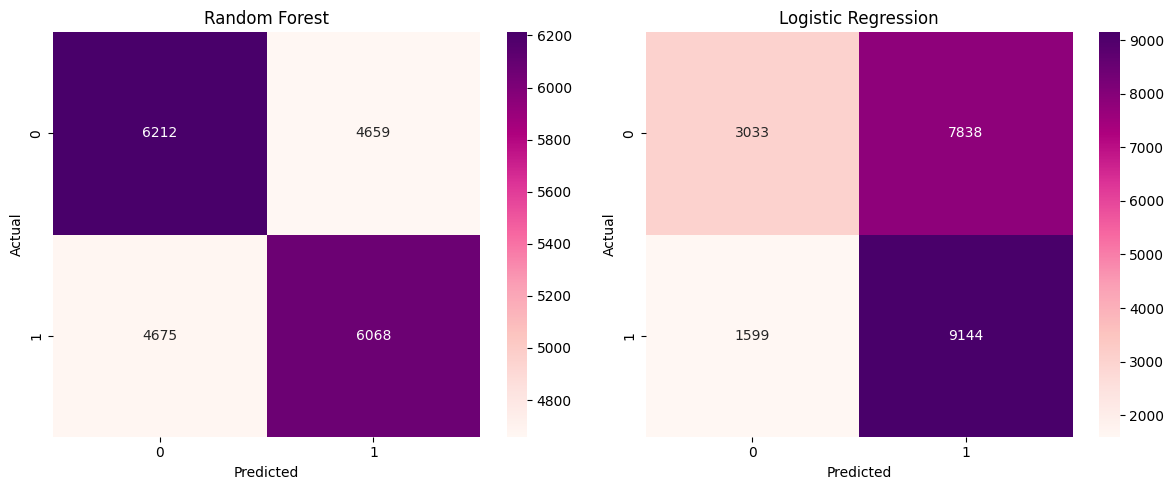

In [19]:
# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Logistic Regression confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Random Forest heatmap
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='RdPu',
    ax=axes[0]
)

axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression heatmap
sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='RdPu',
    ax=axes[1]
)

axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

The confusion matrices compare the Random Forest and Logistic Regression classification models for predicting stock price direction after earnings announcements. The Random Forest model correctly classified 6,212 declining stocks and 6,068 increasing stocks, producing a more balanced performance across both classes. In comparison, the Logistic Regression model correctly identified 9,144 increasing stocks but only 3,033 declining stocks, showing a strong bias toward predicting upward stock movement. While both models achieved similar overall accuracy, the Random Forest model provided more balanced classifications, whereas Logistic Regression performed better at identifying positive stock reactions.

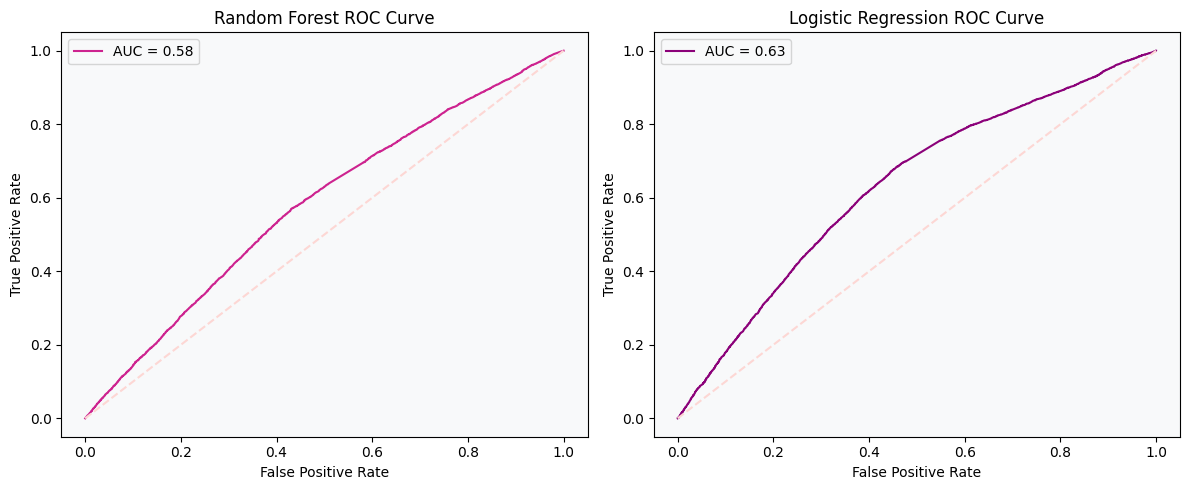

In [20]:
from sklearn.metrics import roc_curve, auc
colors = sns.color_palette("RdPu", 5)

#probabilities for positive class
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]
log_probs = log_model.predict_proba(X_test_scaled)[:,1]

#ROC values
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)

#AUC scores
rf_auc = auc(rf_fpr, rf_tpr)
log_auc = auc(log_fpr, log_tpr)

#create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

#Random Forest ROC
axes[0].plot(rf_fpr, rf_tpr, color=colors[3], label=f'AUC = {rf_auc:.2f}')
axes[0].plot([0,1], [0,1], linestyle='--', color=colors[0])

axes[0].set_title('Random Forest ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

#Logistic Regression ROC
axes[1].plot(log_fpr, log_tpr, color=colors[4], label=f'AUC = {log_auc:.2f}')
axes[1].plot([0,1], [0,1], linestyle='--', color=colors[0])

axes[1].set_title('Logistic Regression ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

The ROC curves and AUC scores further demonstrate the limited predictive strength of both classification models. The Random Forest model achieved an AUC of 0.58, indicating only weak ability to distinguish between stocks that increased and declined after earnings announcements. The Logistic Regression model performed slightly better with an AUC of 0.63, suggesting modest improvement in classification performance but still relatively weak predictive capability overall.

Hierarchial clustering:

Hierarchical clustering was applied as an exploratory unsupervised learning technique to examine whether earnings events naturally grouped together based on EPS surprise metrics and stock price reactions. The selected variables were standardized prior to clustering, and Ward linkage was used to identify similarities and differences among observations through a dendrogram visualization. Due to the large size of the dataset, it was performed on a random sample of 500 observations to explore potential grouping patterns without overloading system memory.

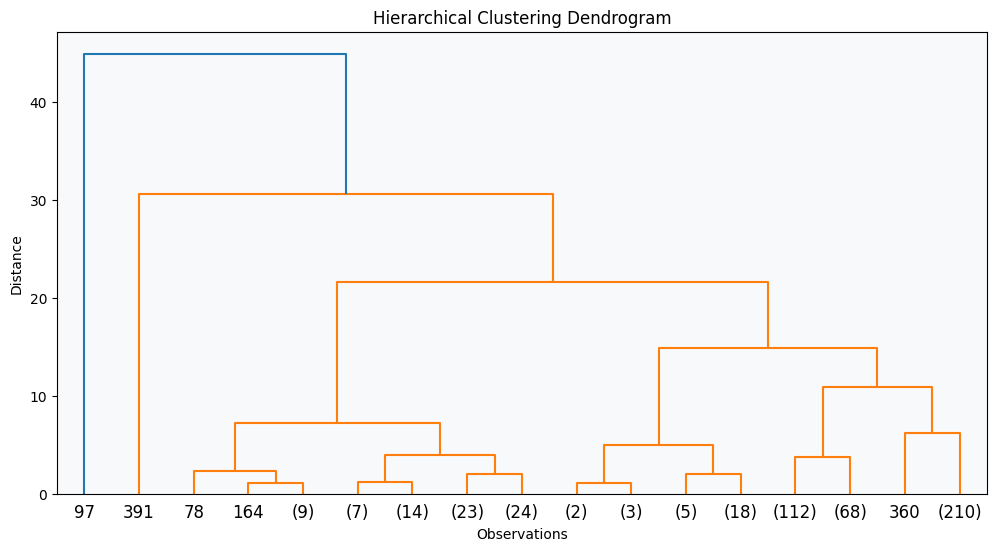

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram

#Select variables

cluster_data = final[[
    'eps_surprise',
    'abs_surprise',
    'surprise_pct',
    'pct_change'
]].dropna()

cluster_sample = cluster_data.sample(
    n=500,
    random_state=42
)

#Scale Data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_sample)

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')

plt.show()



The hierarchical clustering dendrogram suggests the presence of several moderately distinct groupings among earnings events based on EPS surprise characteristics and stock price reactions. Smaller linkage distances indicate observations with more similar earnings behavior, while larger vertical jumps in the dendrogram suggest greater separation between broader clusters. However, the gradual merging structure also indicates substantial overlap among many observations, reinforcing the complexity and variability of market reactions following earnings announcements.